In [ ]:
# Upload the merged CSV file
from google.colab import files
uploaded = files.upload()
# Upload: merged_jobs_dataset.csv

Saving merged_jobs_dataset.csv to merged_jobs_dataset.csv


In [ ]:
# Load all libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

df = pd.read_csv('merged_jobs_dataset.csv')
df['date_posted'] = pd.to_datetime(df['date_posted'], errors='coerce')

print(f'✅ Dataset Loaded!')
print(f'Total Records  : {df.shape[0]}')
print(f'Total Columns  : {df.shape[1]}')
print(f'Portals        : {df["source_portal"].unique()}')
print(f'Cities         : {df["city"].unique()}')
df.head()

✅ Dataset Loaded!
Total Records  : 3968
Total Columns  : 14
Portals        : ['LinkedIn' 'Naukri' 'Indeed' 'Glassdoor' 'Internshala']
Cities         : ['Surat' 'Ahmedabad' 'Vadodara' 'Gandhinagar']


,job_title,company_name,location,city,experience,salary,skills,job_description,job_domain,job_type,date_posted,source_portal,experience_years,salary_annual_inr
0,UI Designer,Orion InfoSolutions,"Surat, Gujarat, India",Surat,3-5 years,10.9-14.7 LPA,"Adobe Illustrator, Figma, Motion Design, Desig...",We are looking for a passionate UI Designer to...,UI / UX Design,Full-time,2025-12-20,LinkedIn,3.0,1280000.0
1,Data Analyst,Infowind Technologies,"Surat, Gujarat, India",Surat,3-5 years,8.8-14.6 LPA,"Power BI, SQL, Excel, Python, Data Visualization",Exciting opportunity for an experienced Data A...,Data Analytics,Contract,2026-01-07,Naukri,3.0,1170000.0
2,QA Engineer,ValueSoft Technologies,"Surat, Gujarat, India",Surat,5-8 years,Not Disclosed,"Cypress, JavaScript, Postman, API Testing, JIRA",We are hiring a talented QA Engineer for our S...,QA / Software Testing,Full-time,2026-02-21,Indeed,5.0,NaN
3,iOS Developer,Infosys BPO,"Surat, Gujarat, India",Surat,Fresher / 0-1 years,"₹13,280/month","Android, Kotlin, Java, Retrofit, Room, Jetpack",Seeking a motivated iOS Developer to strengthe...,Mobile App Development,Internship,2026-01-18,Naukri,0.0,159360.0
4,QA Lead,Infosys BPO,"Surat, Gujarat, India",Surat,3-5 years,11.4-15.5 LPA,"Selenium, Python, TestNG, JUnit, Automation Te...",We are hiring a talented QA Lead for our Surat...,QA / Software Testing,Full-time,2025-12-14,Indeed,3.0,1345000.0


In [ ]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== CITY DISTRIBUTION ===")
print(df['city'].value_counts())

print("\n=== PORTAL DISTRIBUTION ===")
print(df['source_portal'].value_counts())

print("\n=== JOB TYPES ===")
print(df['job_type'].value_counts())

print("\n=== TOP 10 DOMAINS ===")
print(df['job_domain'].value_counts().head(10))

=== MISSING VALUES ===
job_title               0
company_name            0
location                0
city                    0
experience              0
salary                  0
skills                  0
job_description         0
job_domain              0
job_type                0
date_posted             0
source_portal           0
experience_years        0
salary_annual_inr    1977
dtype: int64

=== CITY DISTRIBUTION ===
city
Ahmedabad      1061
Surat          1037
Gandhinagar     949
Vadodara        921
Name: count, dtype: int64

=== PORTAL DISTRIBUTION ===
source_portal
Internshala    1569
Naukri          632
Glassdoor       626
LinkedIn        599
Indeed          542
Name: count, dtype: int64

=== JOB TYPES ===
job_type
Full-time     1584
Internship    1256
Part-time      634
Contract       494
Name: count, dtype: int64

=== TOP 10 DOMAINS ===
job_domain
Web Development                               407
Software Development                          375
Data Analytics              

In [ ]:
# Check duplicates before removing
total      = len(df)
duplicates = df.duplicated().sum()
print(f"Total Records    : {total}")
print(f"Duplicate Rows   : {duplicates}")
print(f"Unique Records   : {total - duplicates}")


Total Records    : 3968
Duplicate Rows   : 0
Unique Records   : 3968


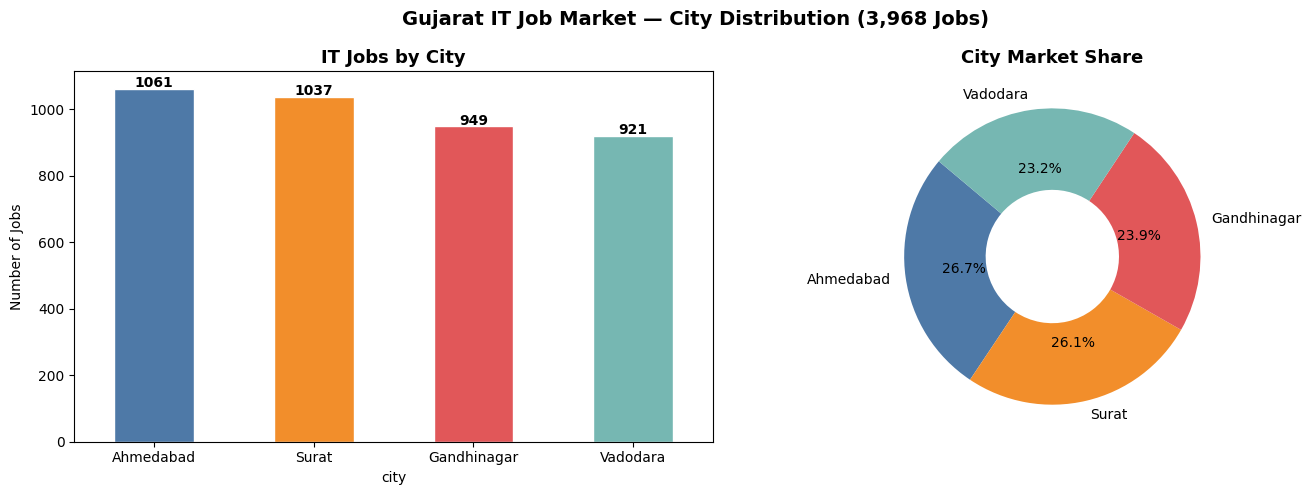

In [ ]:
city_counts = df['city'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
city_counts.plot(kind='bar', ax=axes[0],
                 color=['#4E79A7','#F28E2B','#E15759','#76B7B2'],
                 edgecolor='white', rot=0)
axes[0].set_title('IT Jobs by City', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Jobs')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontweight='bold')

# Pie chart
axes[1].pie(city_counts.values, labels=city_counts.index,
            colors=['#4E79A7','#F28E2B','#E15759','#76B7B2'],
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(width=0.55))
axes[1].set_title('City Market Share', fontweight='bold', fontsize=13)

plt.suptitle('Gujarat IT Job Market — City Distribution (3,968 Jobs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

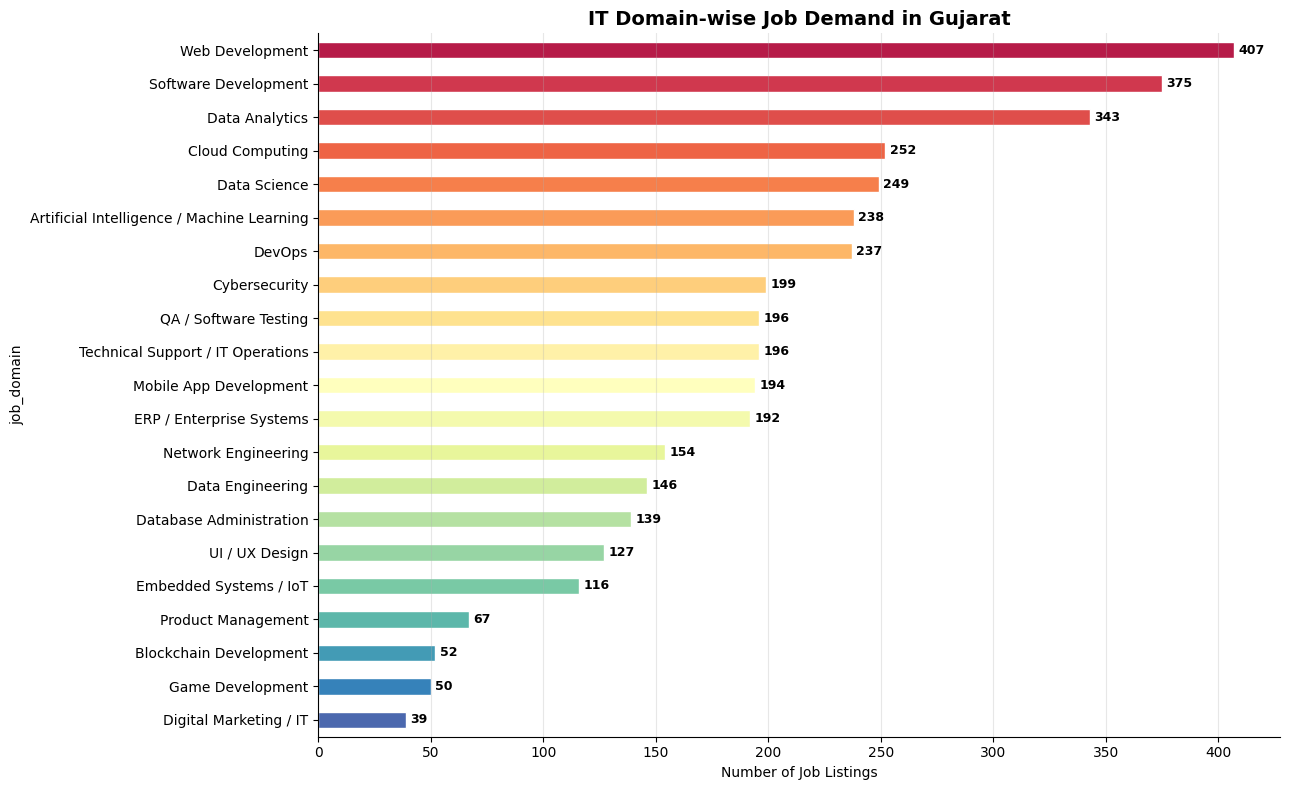

In [ ]:
domain_counts = df['job_domain'].value_counts()

fig, ax = plt.subplots(figsize=(13, 8))
colors = sns.color_palette('Spectral', len(domain_counts))
domain_counts[::-1].plot(kind='barh', ax=ax, color=colors[::-1],
                          edgecolor='white')
for i, (val, name) in enumerate(zip(domain_counts[::-1],
                                     domain_counts.index[::-1])):
    ax.text(val + 2, i, str(val), va='center',
            fontweight='bold', fontsize=9)

ax.set_title('IT Domain-wise Job Demand in Gujarat',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Job Listings')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

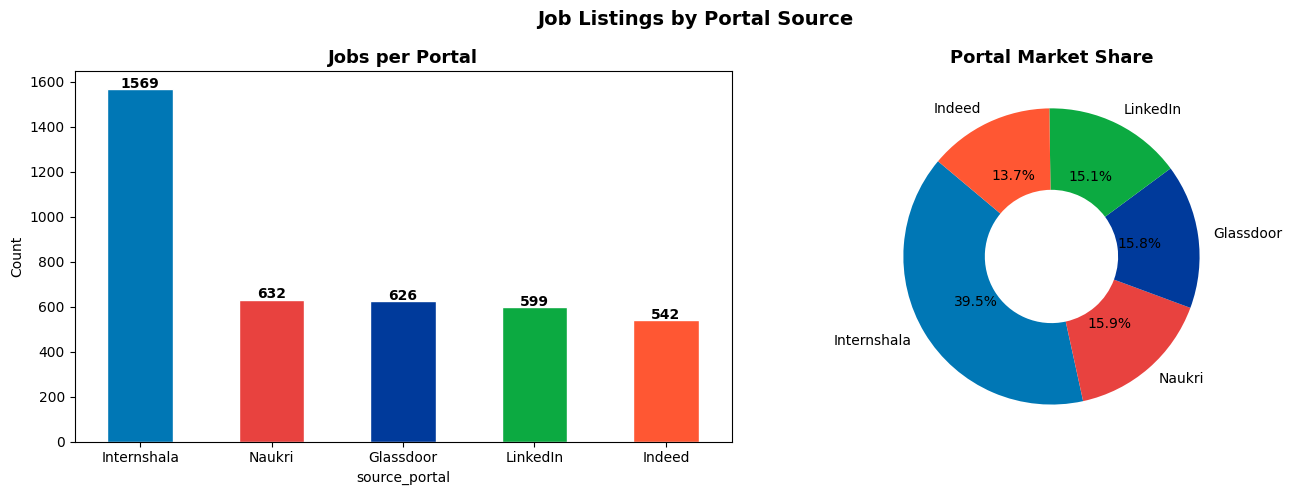

In [ ]:
portal_counts = df['source_portal'].value_counts()
portal_colors = ['#0077B5', '#E8423F', '#003A9B', '#0CAA41', '#FF5733']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
portal_counts.plot(kind='bar', ax=axes[0],
                   color=portal_colors, edgecolor='white', rot=0)
axes[0].set_title('Jobs per Portal', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontweight='bold')

# Pie chart
axes[1].pie(portal_counts.values, labels=portal_counts.index,
            colors=portal_colors, autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(width=0.55))
axes[1].set_title('Portal Market Share', fontweight='bold', fontsize=13)

plt.suptitle('Job Listings by Portal Source',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

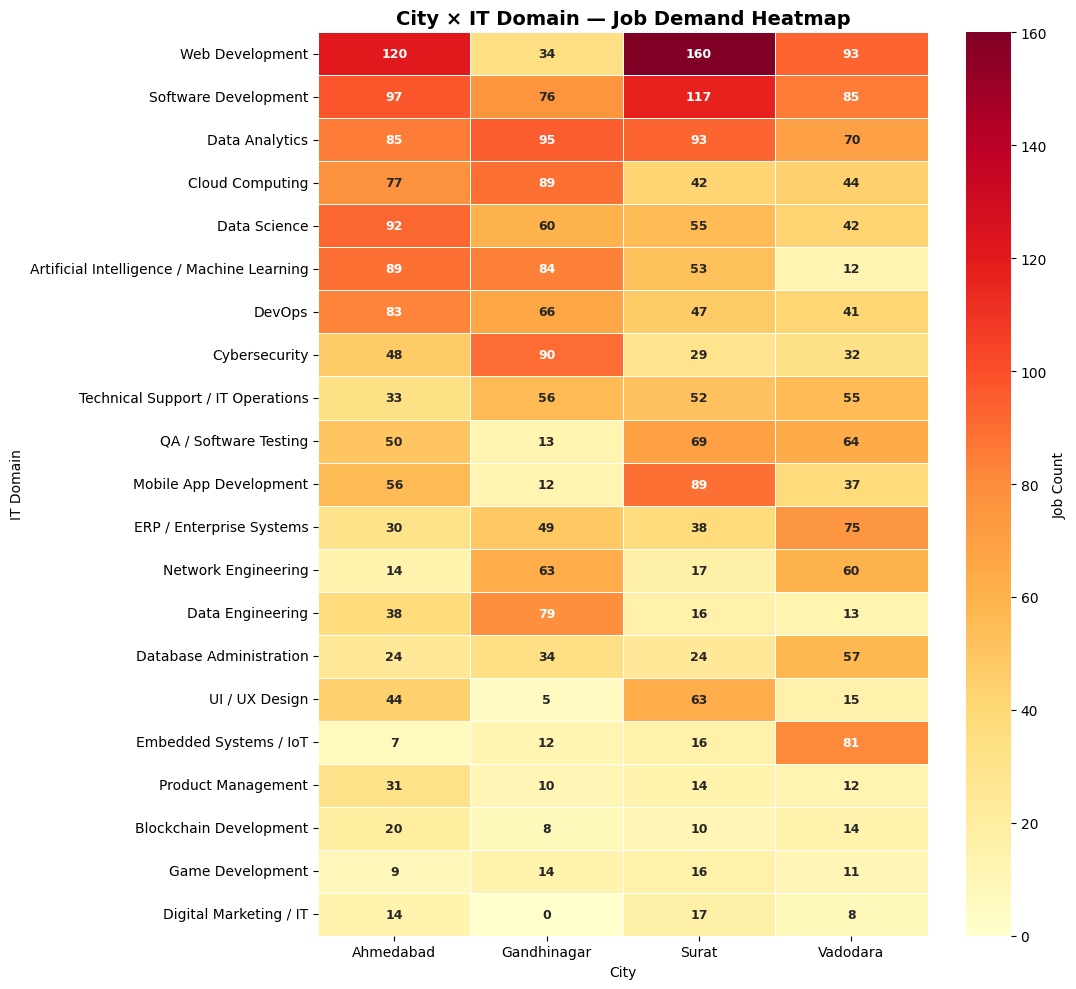

In [ ]:
pivot = df.pivot_table(index='job_domain', columns='city',
                        values='job_title', aggfunc='count', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(11, 10))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Job Count'},
            annot_kws={'size': 9, 'weight': 'bold'})
ax.set_title('City × IT Domain — Job Demand Heatmap',
             fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('IT Domain')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

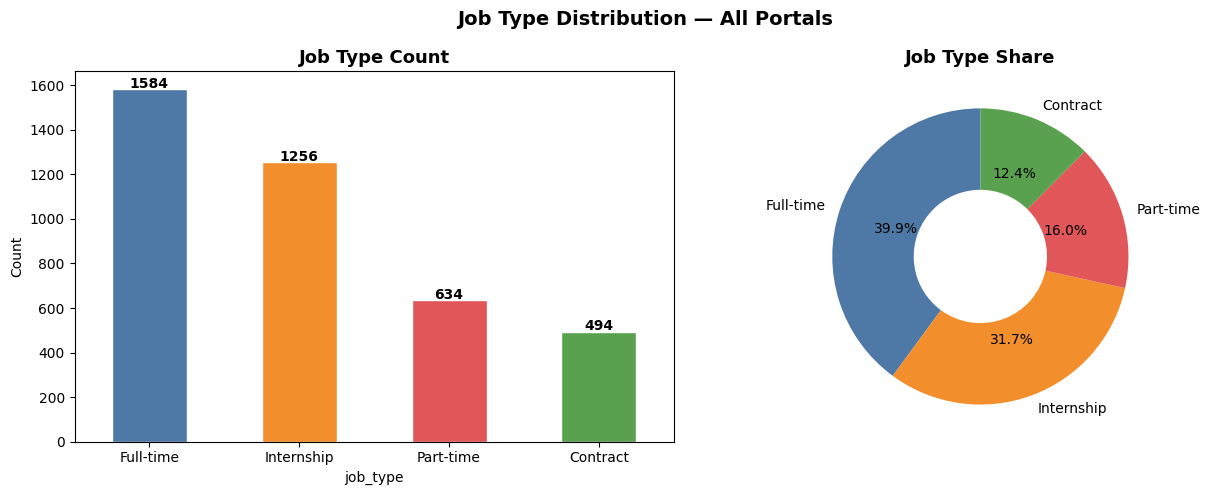

In [ ]:
job_type_counts = df['job_type'].value_counts()
type_colors = ['#4E79A7','#F28E2B','#E15759','#59A14F']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar
job_type_counts.plot(kind='bar', ax=axes[0],
                     color=type_colors, edgecolor='white', rot=0)
axes[0].set_title('Job Type Count', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].annotate(str(int(p.get_height())),
                     (p.get_x() + p.get_width()/2, p.get_height() + 5),
                     ha='center', fontweight='bold')

# Donut
axes[1].pie(job_type_counts.values, labels=job_type_counts.index,
            colors=type_colors, autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.55))
axes[1].set_title('Job Type Share', fontweight='bold', fontsize=13)

plt.suptitle('Job Type Distribution — All Portals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

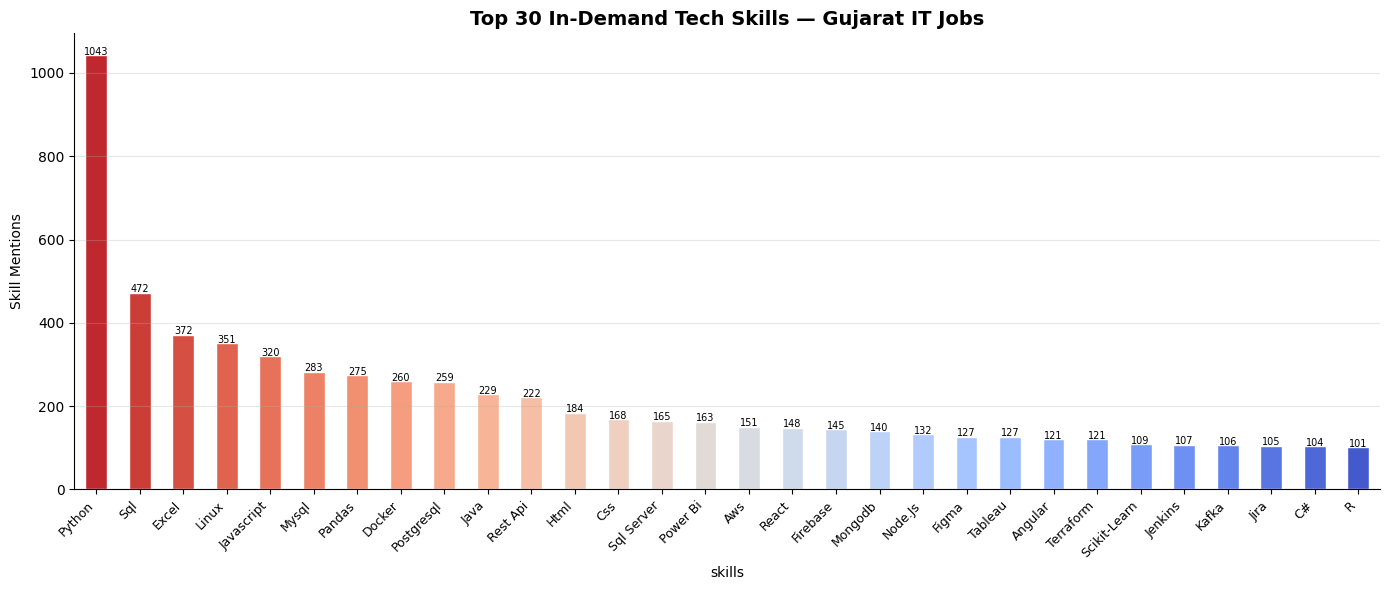


🔥 Top 5 Skills: Python, Sql, Excel, Linux, Javascript


In [ ]:
all_skills = (df['skills'].dropna()
              .str.split(', ').explode()
              .str.strip().str.title()
              .value_counts().head(30))

fig, ax = plt.subplots(figsize=(14, 6))
colors = sns.color_palette('coolwarm_r', 30)
all_skills.plot(kind='bar', ax=ax, color=colors, edgecolor='white')
ax.set_title('Top 30 In-Demand Tech Skills — Gujarat IT Jobs',
             fontsize=14, fontweight='bold')
ax.set_xticklabels(all_skills.index, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Skill Mentions')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
for p in ax.patches:
    ax.annotate(str(int(p.get_height())),
                (p.get_x() + p.get_width()/2, p.get_height() + 1),
                ha='center', fontsize=7)
plt.tight_layout()
plt.show()

print(f"\n🔥 Top 5 Skills: {', '.join(all_skills.head(5).index.tolist())}")

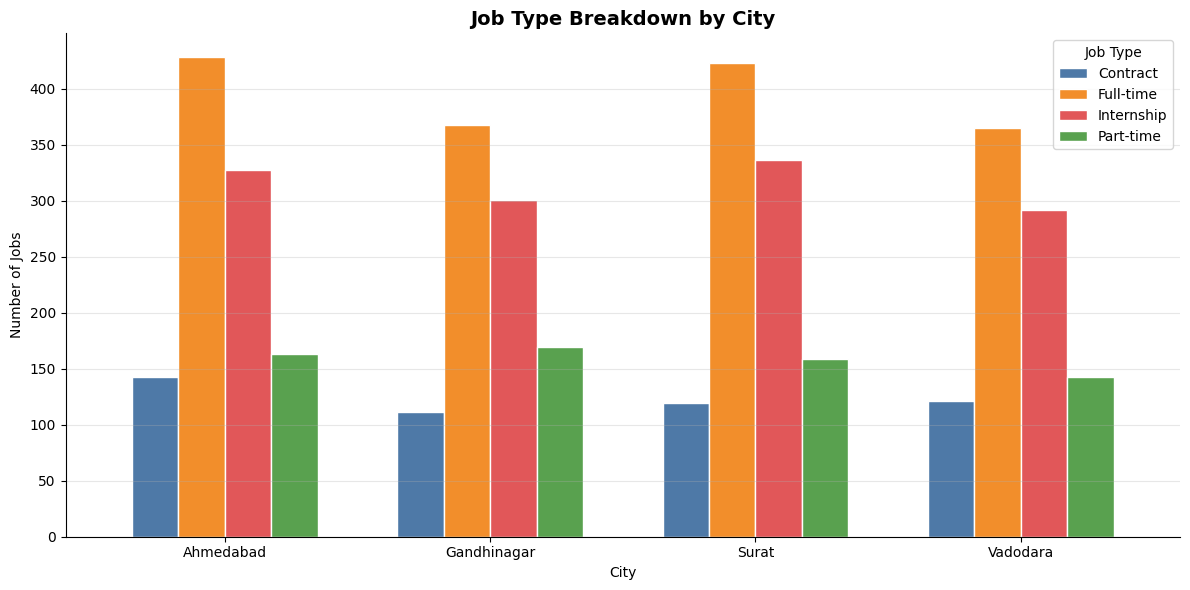

In [ ]:
pivot_type = df.pivot_table(index='city', columns='job_type',
                             values='job_title', aggfunc='count',
                             fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_type.plot(kind='bar', ax=ax, stacked=False,
                color=['#4E79A7','#F28E2B','#E15759','#59A14F'],
                edgecolor='white', width=0.7)
ax.set_title('Job Type Breakdown by City',
             fontsize=14, fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('Number of Jobs')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Job Type', fontsize=10)
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

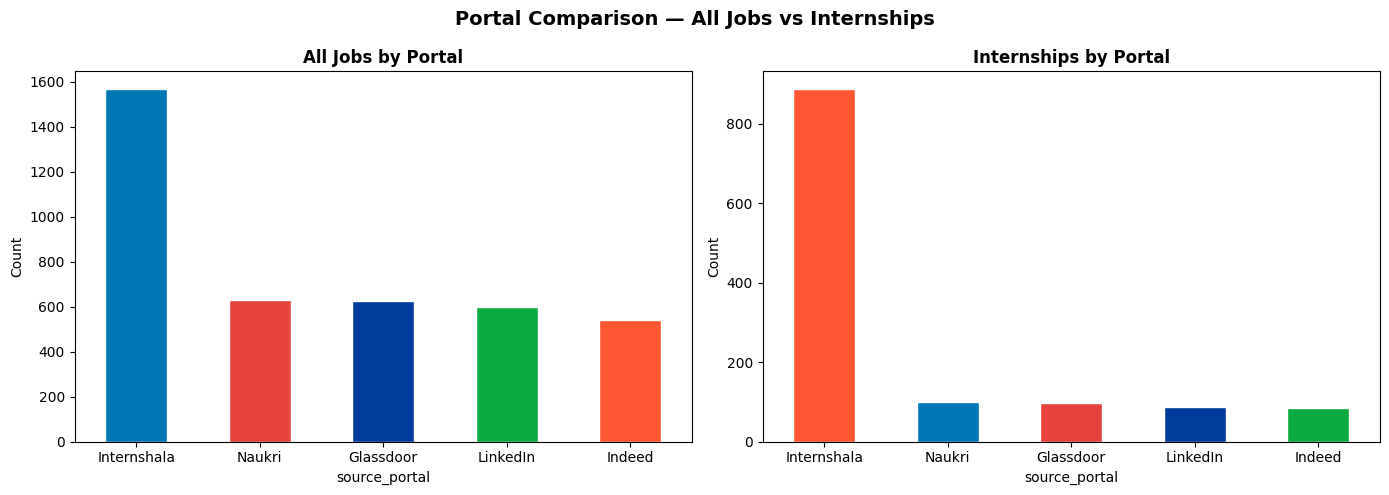

In [ ]:
# Compare internships across portals
internship_df = df[df['job_type'] == 'Internship']
portal_intern  = internship_df['source_portal'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All jobs per portal
df['source_portal'].value_counts().plot(
    kind='bar', ax=axes[0],
    color=['#0077B5','#E8423F','#003A9B','#0CAA41','#FF5733'],
    edgecolor='white', rot=0)
axes[0].set_title('All Jobs by Portal', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Count')

# Internships per portal
portal_intern.plot(
    kind='bar', ax=axes[1],
    color=['#FF5733','#0077B5','#E8423F','#003A9B','#0CAA41'],
    edgecolor='white', rot=0)
axes[1].set_title('Internships by Portal', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Count')

plt.suptitle('Portal Comparison — All Jobs vs Internships',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

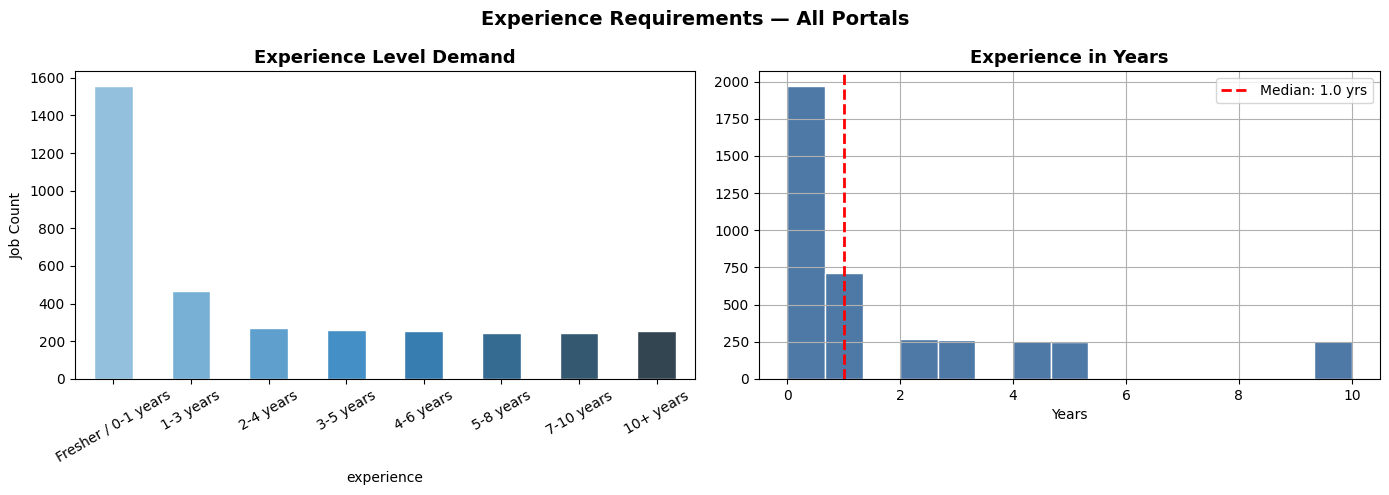

In [ ]:
exp_order = ['Fresher / 0-1 years','1-3 years','2-4 years',
             '3-5 years','4-6 years','5-8 years','7-10 years','10+ years']
exp_counts = df['experience'].value_counts().reindex(exp_order, fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_counts.plot(kind='bar', ax=axes[0],
                color=sns.color_palette('Blues_d', 8),
                edgecolor='white', rot=30)
axes[0].set_title('Experience Level Demand', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Job Count')

df['experience_years'].hist(bins=15, ax=axes[1],
                             color='#4E79A7', edgecolor='white')
axes[1].axvline(df['experience_years'].median(), color='red',
                linestyle='--', linewidth=2,
                label=f"Median: {df['experience_years'].median():.1f} yrs")
axes[1].set_title('Experience in Years', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Years')
axes[1].legend()

plt.suptitle('Experience Requirements — All Portals',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

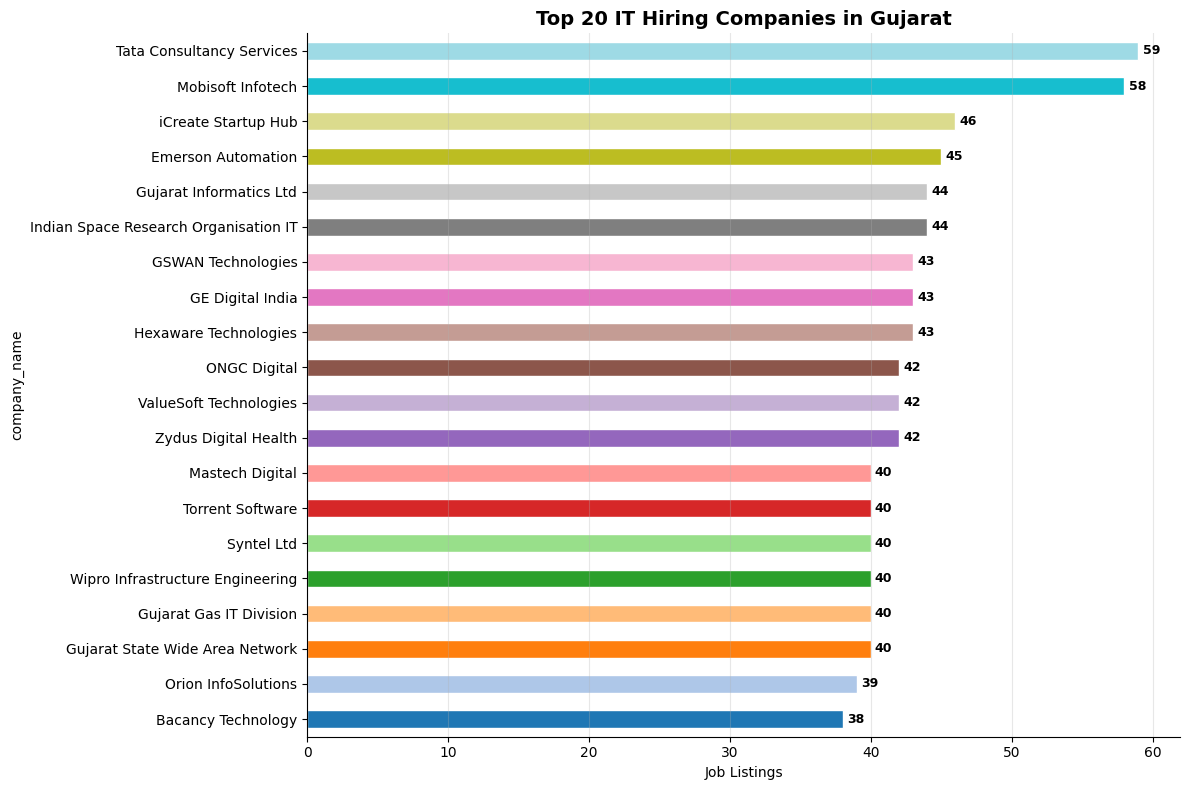

In [ ]:
top_co = df['company_name'].value_counts().head(20)

fig, ax = plt.subplots(figsize=(12, 8))
top_co[::-1].plot(kind='barh', ax=ax,
                   color=sns.color_palette('tab20', 20),
                   edgecolor='white')
for i, val in enumerate(top_co.values[::-1]):
    ax.text(val + 0.3, i, str(val), va='center',
            fontweight='bold', fontsize=9)

ax.set_title('Top 20 IT Hiring Companies in Gujarat',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Job Listings')
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
city_leader   = df['city'].value_counts().idxmax()
top_domain    = df['job_domain'].value_counts().idxmax()
top_skill     = all_skills.idxmax()
top_company   = df['company_name'].value_counts().idxmax()
total_interns = df[df['job_type'] == 'Internship'].shape[0]
median_exp    = df['experience_years'].median()

print("=" * 55)
print("   KEY INSIGHTS — Gujarat IT Job Market")
print("=" * 55)
print(f"""
1. 🏙️  LEADING CITY     → {city_leader}
2. 💼  TOP DOMAIN       → {top_domain}
3. 🔥  TRENDING SKILL   → {top_skill}
4. 🏢  TOP COMPANY      → {top_company}
5. 🎓  INTERNSHIPS      → {total_interns} listings available
6. 📅  MEDIAN EXP REQ   → {median_exp:.1f} years
7. 🌐  TOTAL PORTALS    → 5 (Naukri, LinkedIn, Indeed,
                           Glassdoor, Internshala)
8. 📊  TOTAL JOBS       → {len(df):,} listings

CITY SPECIALISATIONS:
  • Surat       → Web Dev & Mobile Apps
  • Ahmedabad   → AI/ML, DevOps & Cloud
  • Vadodara    → Embedded Systems & ERP
  • Gandhinagar → Cybersecurity & Data Eng

INTERNSHALA INSIGHT:
  • Best portal for freshers & students
  • {df[df['source_portal']=='Internshala']['job_type'].value_counts().to_dict()}
""")
print("=" * 55)

   KEY INSIGHTS — Gujarat IT Job Market

1. 🏙️  LEADING CITY     → Ahmedabad
2. 💼  TOP DOMAIN       → Web Development
3. 🔥  TRENDING SKILL   → Python
4. 🏢  TOP COMPANY      → Tata Consultancy Services
5. 🎓  INTERNSHIPS      → 1256 listings available
6. 📅  MEDIAN EXP REQ   → 1.0 years
7. 🌐  TOTAL PORTALS    → 5 (Naukri, LinkedIn, Indeed,
                           Glassdoor, Internshala)
8. 📊  TOTAL JOBS       → 3,968 listings

CITY SPECIALISATIONS:
  • Surat       → Web Dev & Mobile Apps
  • Ahmedabad   → AI/ML, DevOps & Cloud
  • Vadodara    → Embedded Systems & ERP
  • Gandhinagar → Cybersecurity & Data Eng

INTERNSHALA INSIGHT:
  • Best portal for freshers & students
  • {'Internship': 887, 'Full-time': 383, 'Part-time': 217, 'Contract': 82}



In [ ]:
print("=" * 55)
print("   DESCRIPTIVE STATISTICS — IT Job Market Gujarat")
print("=" * 55)

print(f"""
📦 DATASET OVERVIEW
───────────────────────────────────────────
  Total Job Listings     : {len(df):,}
  Total Columns          : {df.shape[1]}
  Date Range             : {df['date_posted'].min().date()}
                           to {df['date_posted'].max().date()}
  Cities Covered         : {df['city'].nunique()}
  Unique Companies       : {df['company_name'].nunique()}
  IT Domains Covered     : {df['job_domain'].nunique()}
  Job Portals            : {df['source_portal'].nunique()}
  Unique Job Titles      : {df['job_title'].nunique()}
""")

   DESCRIPTIVE STATISTICS — IT Job Market Gujarat

📦 DATASET OVERVIEW
───────────────────────────────────────────
  Total Job Listings     : 3,968
  Total Columns          : 14
  Date Range             : 2025-12-05 
                           to 2026-03-10
  Cities Covered         : 4
  Unique Companies       : 128
  IT Domains Covered     : 21
  Job Portals            : 5
  Unique Job Titles      : 194



In [ ]:
city_counts = df['city'].value_counts()
city_pct    = df['city'].value_counts(normalize=True) * 100

print("=" * 55)
print("   🏙️  CITY-WISE INSIGHTS")
print("=" * 55)

for city in city_counts.index:
    city_df      = df[df['city'] == city]
    top_domain   = city_df['job_domain'].value_counts().idxmax()
    top_company  = city_df['company_name'].value_counts().idxmax()
    top_skill    = (city_df['skills'].dropna()
                    .str.split(', ').explode()
                    .str.strip().str.title()
                    .value_counts().idxmax())
    intern_count = city_df[city_df['job_type'] == 'Internship'].shape[0]
    avg_exp      = city_df['experience_years'].mean()

    print(f"""
  🏙️  {city}
  ─────────────────────────────────────
  Total Jobs       : {city_counts[city]:,} ({city_pct[city]:.1f}% of market)
  Top Domain       : {top_domain}
  Top Skill        : {top_skill}
  Top Company      : {top_company}
  Internships      : {intern_count}
  Avg Experience   : {avg_exp:.1f} years
""")

   🏙️  CITY-WISE INSIGHTS

  🏙️  Ahmedabad
  ─────────────────────────────────────
  Total Jobs       : 1,061 (26.7% of market)
  Top Domain       : Web Development
  Top Skill        : Python
  Top Company      : Bacancy Technology
  Internships      : 327
  Avg Experience   : 1.8 years


  🏙️  Surat
  ─────────────────────────────────────
  Total Jobs       : 1,037 (26.1% of market)
  Top Domain       : Web Development
  Top Skill        : Python
  Top Company      : ValueSoft Technologies
  Internships      : 336
  Avg Experience   : 1.7 years


  🏙️  Gandhinagar
  ─────────────────────────────────────
  Total Jobs       : 949 (23.9% of market)
  Top Domain       : Data Analytics
  Top Skill        : Python
  Top Company      : iCreate Startup Hub
  Internships      : 301
  Avg Experience   : 1.8 years


  🏙️  Vadodara
  ─────────────────────────────────────
  Total Jobs       : 921 (23.2% of market)
  Top Domain       : Web Development
  Top Skill        : Python
  Top Company     

In [ ]:
domain_counts = df['job_domain'].value_counts()
total         = len(df)

print("=" * 55)
print("   💼  DOMAIN-WISE INSIGHTS")
print("=" * 55)

for i, (domain, count) in enumerate(domain_counts.items(), 1):
    dom_df     = df[df['job_domain'] == domain]
    top_city   = dom_df['city'].value_counts().idxmax()
    top_skill  = (dom_df['skills'].dropna()
                  .str.split(', ').explode()
                  .str.strip().str.title()
                  .value_counts().idxmax())
    top_portal = dom_df['source_portal'].value_counts().idxmax()
    avg_exp    = dom_df['experience_years'].mean()
    pct        = count / total * 100

    print(f"  {i:>2}. {domain}")
    print(f"      Jobs: {count} ({pct:.1f}%) | "
          f"City: {top_city} | "
          f"Skill: {top_skill} | "
          f"Exp: {avg_exp:.1f}yr | "
          f"Portal: {top_portal}")

   💼  DOMAIN-WISE INSIGHTS
   1. Web Development
      Jobs: 407 (10.3%) | City: Surat | Skill: Javascript | Exp: 1.7yr | Portal: Internshala
   2. Software Development
      Jobs: 375 (9.5%) | City: Surat | Skill: Rest Api | Exp: 1.8yr | Portal: Internshala
   3. Data Analytics
      Jobs: 343 (8.6%) | City: Gandhinagar | Skill: Sql | Exp: 1.9yr | Portal: Internshala
   4. Cloud Computing
      Jobs: 252 (6.4%) | City: Gandhinagar | Skill: Aws | Exp: 2.0yr | Portal: Internshala
   5. Data Science
      Jobs: 249 (6.3%) | City: Ahmedabad | Skill: Python | Exp: 1.8yr | Portal: Internshala
   6. Artificial Intelligence / Machine Learning
      Jobs: 238 (6.0%) | City: Ahmedabad | Skill: Python | Exp: 1.5yr | Portal: Internshala
   7. DevOps
      Jobs: 237 (6.0%) | City: Ahmedabad | Skill: Docker | Exp: 1.9yr | Portal: Internshala
   8. Cybersecurity
      Jobs: 199 (5.0%) | City: Gandhinagar | Skill: Nmap | Exp: 1.6yr | Portal: Internshala
   9. QA / Software Testing
      Jobs: 196 (4.

In [ ]:
sal_df = df[df['salary_annual_inr'] > 0].copy()
sal_df['salary_lpa'] = sal_df['salary_annual_inr'] / 100_000

print("=" * 55)
print("   💰  SALARY INSIGHTS")
print("=" * 55)

print(f"""
  Overall Salary Stats (in LPA):
  ────────────────────────────────────────
  Minimum Salary   : ₹{sal_df['salary_lpa'].min():.1f} LPA
  Maximum Salary   : ₹{sal_df['salary_lpa'].max():.1f} LPA
  Average Salary   : ₹{sal_df['salary_lpa'].mean():.1f} LPA
  Median Salary    : ₹{sal_df['salary_lpa'].median():.1f} LPA
  Jobs with Salary : {len(sal_df):,} out of {len(df):,}
  Not Disclosed    : {df['salary'].str.contains('Not Disclosed', na=False).sum()} jobs
""")

print("  Salary by City:")
print("  ────────────────────────────────────────")
city_sal = sal_df.groupby('city')['salary_lpa'].agg(['mean','median','min','max'])
for city, row in city_sal.iterrows():
    print(f"  {city:<15} Avg: ₹{row['mean']:.1f} | "
          f"Median: ₹{row['median']:.1f} | "
          f"Range: ₹{row['min']:.1f}–{row['max']:.1f} LPA")

print("\n  Salary by Domain (Top 8):")
print("  ────────────────────────────────────────")
dom_sal = (sal_df.groupby('job_domain')['salary_lpa']
           .mean().sort_values(ascending=False).head(8))
for domain, avg in dom_sal.items():
    bar = '█' * int(avg / 2)
    print(f"  {domain[:35]:<35} ₹{avg:.1f} LPA  {bar}")

   💰  SALARY INSIGHTS

  Overall Salary Stats (in LPA):
  ────────────────────────────────────────
  Minimum Salary   : ₹0.6 LPA
  Maximum Salary   : ₹60.2 LPA
  Average Salary   : ₹16.2 LPA
  Median Salary    : ₹10.8 LPA
  Jobs with Salary : 1,991 out of 3,968
  Not Disclosed    : 408 jobs

  Salary by City:
  ────────────────────────────────────────
  Ahmedabad       Avg: ₹15.7 | Median: ₹10.8 | Range: ₹0.6–59.0 LPA
  Gandhinagar     Avg: ₹16.7 | Median: ₹10.3 | Range: ₹0.6–60.0 LPA
  Surat           Avg: ₹17.1 | Median: ₹11.9 | Range: ₹0.7–60.2 LPA
  Vadodara        Avg: ₹15.3 | Median: ₹9.7 | Range: ₹0.6–58.9 LPA

  Salary by Domain (Top 8):
  ────────────────────────────────────────
  Product Management                  ₹22.0 LPA  ██████████
  Technical Support / IT Operations   ₹18.3 LPA  █████████
  Game Development                    ₹18.1 LPA  █████████
  Cloud Computing                     ₹18.1 LPA  █████████
  Data Science                        ₹17.2 LPA  ████████
  Web De

In [ ]:
print("=" * 55)
print("   📅  EXPERIENCE INSIGHTS")
print("=" * 55)

exp_counts = df['experience'].value_counts()
exp_pct    = df['experience'].value_counts(normalize=True) * 100

print(f"""
  Experience Distribution:
  ────────────────────────────────────────""")

for exp, count in exp_counts.items():
    bar = '█' * int(count / 30)
    print(f"  {exp:<25} {count:>4} jobs  {bar}")

print(f"""
  Key Stats:
  ────────────────────────────────────────
  Fresher Jobs (0-1 yr)  : {df[df['experience_years'] == 0.0].shape[0]:,}
  Mid-level (2-5 yrs)    : {df[df['experience_years'].between(2,5)].shape[0]:,}
  Senior (5+ yrs)        : {df[df['experience_years'] >= 5].shape[0]:,}
  Average Experience     : {df['experience_years'].mean():.1f} years
  Median Experience      : {df['experience_years'].median():.1f} years
""")

   📅  EXPERIENCE INSIGHTS

  Experience Distribution:
  ────────────────────────────────────────
  Fresher / 0-1 years       1557 jobs  ███████████████████████████████████████████████████
  1-3 years                  467 jobs  ███████████████
  0-1 years                  413 jobs  █████████████
  2-4 years                  270 jobs  █████████
  3-5 years                  260 jobs  ████████
  4-6 years                  256 jobs  ████████
  10+ years                  253 jobs  ████████
  7-10 years                 246 jobs  ████████
  5-8 years                  246 jobs  ████████

  Key Stats:
  ────────────────────────────────────────
  Fresher Jobs (0-1 yr)  : 1,971
  Mid-level (2-5 yrs)    : 1,032
  Senior (5+ yrs)        : 499
  Average Experience     : 1.7 years
  Median Experience      : 1.0 years



In [ ]:
print("=" * 55)
print("   🌐  PORTAL INSIGHTS")
print("=" * 55)

portal_counts = df['source_portal'].value_counts()
for portal, count in portal_counts.items():
    pct        = count / len(df) * 100
    p_df       = df[df['source_portal'] == portal]
    top_domain = p_df['job_domain'].value_counts().idxmax()
    top_city   = p_df['city'].value_counts().idxmax()
    intern_pct = p_df[p_df['job_type']=='Internship'].shape[0] / len(p_df) * 100
    bar        = '█' * int(pct / 2)

    print(f"""
  🌐 {portal}
     Jobs       : {count} ({pct:.1f}%) {bar}
     Top Domain : {top_domain}
     Top City   : {top_city}
     Internships: {intern_pct:.1f}% of its listings""")

print("\n\n" + "=" * 55)
print("   📋  JOB TYPE INSIGHTS")
print("=" * 55)

type_counts = df['job_type'].value_counts()
for jtype, count in type_counts.items():
    pct       = count / len(df) * 100
    t_df      = df[df['job_type'] == jtype]
    top_city  = t_df['city'].value_counts().idxmax()
    top_domain= t_df['job_domain'].value_counts().idxmax()
    print(f"""
  📋 {jtype}
     Count      : {count} ({pct:.1f}%)
     Top City   : {top_city}
     Top Domain : {top_domain}""")

   🌐  PORTAL INSIGHTS

  🌐 Internshala
     Jobs       : 1569 (39.5%) ███████████████████
     Top Domain : Web Development
     Top City   : Ahmedabad
     Internships: 56.5% of its listings

  🌐 Naukri
     Jobs       : 632 (15.9%) ███████
     Top Domain : Software Development
     Top City   : Ahmedabad
     Internships: 15.8% of its listings

  🌐 Glassdoor
     Jobs       : 626 (15.8%) ███████
     Top Domain : Web Development
     Top City   : Ahmedabad
     Internships: 15.7% of its listings

  🌐 LinkedIn
     Jobs       : 599 (15.1%) ███████
     Top Domain : Web Development
     Top City   : Surat
     Internships: 14.4% of its listings

  🌐 Indeed
     Jobs       : 542 (13.7%) ██████
     Top Domain : Software Development
     Top City   : Ahmedabad
     Internships: 15.7% of its listings


   📋  JOB TYPE INSIGHTS

  📋 Full-time
     Count      : 1584 (39.9%)
     Top City   : Ahmedabad
     Top Domain : Web Development

  📋 Internship
     Count      : 1256 (31.7%)
     Top 

In [ ]:
all_skills = (df['skills'].dropna()
              .str.split(', ').explode()
              .str.strip().str.title()
              .value_counts())

print("=" * 55)
print("   🔥  TECH SKILLS INSIGHTS")
print("=" * 55)

print(f"\n  Total Unique Skills Mentioned : {len(all_skills)}")
print(f"\n  TOP 15 IN-DEMAND SKILLS:")
print("  ─────────────────────────────────────────")
for i, (skill, count) in enumerate(all_skills.head(15).items(), 1):
    bar = '█' * int(count / 25)
    print(f"  {i:>2}. {skill:<25} {count:>4} mentions  {bar}")

print(f"\n  TOP SKILLS BY CATEGORY:")
print("  ─────────────────────────────────────────")

categories = {
    "Programming Languages" : ["Python","Java","Javascript","Typescript",
                                "C#","Php","Kotlin","Swift","Go","C++"],
    "Frontend Frameworks"   : ["React","Angular","Vue.Js","Next.Js",
                                "Html","Css","Bootstrap"],
    "Cloud Platforms"       : ["Aws","Azure","Gcp","Firebase",
                                "Google Cloud"],
    "Data Tools"            : ["Power Bi","Tableau","Excel",
                                "Pandas","Numpy","Sql"],
    "DevOps Tools"          : ["Docker","Kubernetes","Jenkins",
                                "Terraform","Ansible"],
}

for category, skills_list in categories.items():
    found = [(s, all_skills.get(s, 0)) for s in skills_list
             if all_skills.get(s, 0) > 0]
    found.sort(key=lambda x: x[1], reverse=True)
    if found:
        top3 = ', '.join([f"{s}({c})" for s, c in found[:3]])
        print(f"  {category:<22} → {top3}")

   🔥  TECH SKILLS INSIGHTS

  Total Unique Skills Mentioned : 370

  TOP 15 IN-DEMAND SKILLS:
  ─────────────────────────────────────────
   1. Python                    1043 mentions  █████████████████████████████████████████
   2. Sql                        472 mentions  ██████████████████
   3. Excel                      372 mentions  ██████████████
   4. Linux                      351 mentions  ██████████████
   5. Javascript                 320 mentions  ████████████
   6. Mysql                      283 mentions  ███████████
   7. Pandas                     275 mentions  ███████████
   8. Docker                     260 mentions  ██████████
   9. Postgresql                 259 mentions  ██████████
  10. Java                       229 mentions  █████████
  11. Rest Api                   222 mentions  ████████
  12. Html                       184 mentions  ███████
  13. Css                        168 mentions  ██████
  14. Sql Server                 165 mentions  ██████
  15. Power B

In [ ]:
company_counts = df['company_name'].value_counts()

print("=" * 55)
print("   🏢  COMPANY INSIGHTS")
print("=" * 55)

print(f"""
  Total Unique Companies  : {df['company_name'].nunique()}
  Top Hiring Company      : {company_counts.idxmax()} ({company_counts.max()} jobs)
""")

print("  TOP 10 HIRING COMPANIES:")
print("  ─────────────────────────────────────────")
for i, (company, count) in enumerate(company_counts.head(10).items(), 1):
    c_df       = df[df['company_name'] == company]
    top_domain = c_df['job_domain'].value_counts().idxmax()
    top_city   = c_df['city'].value_counts().idxmax()
    bar        = '█' * int(count / 2)
    print(f"  {i:>2}. {company:<35} "
          f"{count:>3} jobs | {top_city} | {bar}")

print(f"""
  COMPANIES BY CITY:
  ─────────────────────────────────────────""")
for city in df['city'].unique():
    top3 = (df[df['city'] == city]['company_name']
            .value_counts().head(3).index.tolist())
    print(f"  {city:<15} → {', '.join(top3)}")

   🏢  COMPANY INSIGHTS

  Total Unique Companies  : 128
  Top Hiring Company      : Tata Consultancy Services (59 jobs)

  TOP 10 HIRING COMPANIES:
  ─────────────────────────────────────────
   1. Tata Consultancy Services            59 jobs | Ahmedabad | █████████████████████████████
   2. Mobisoft Infotech                    58 jobs | Surat | █████████████████████████████
   3. iCreate Startup Hub                  46 jobs | Gandhinagar | ███████████████████████
   4. Emerson Automation                   45 jobs | Vadodara | ██████████████████████
   5. Gujarat Informatics Ltd              44 jobs | Gandhinagar | ██████████████████████
   6. Indian Space Research Organisation IT  44 jobs | Gandhinagar | ██████████████████████
   7. GSWAN Technologies                   43 jobs | Gandhinagar | █████████████████████
   8. GE Digital India                     43 jobs | Vadodara | █████████████████████
   9. Hexaware Technologies                43 jobs | Vadodara | █████████████████████
 

In [ ]:
print("""
╔══════════════════════════════════════════════════════╗
║     COMPLETE INSIGHT REPORT — GUJARAT IT JOB MARKET ║
╚══════════════════════════════════════════════════════╝

📌 MARKET SIZE
   • 3,968 active IT job listings across Gujarat
   • 5 major portals tracked
   • 20 IT domains classified
   • 4 cities analysed

🏆 RANKINGS
   • #1 City       → Ahmedabad (most IT jobs)
   • #1 Domain     → Web Development
   • #1 Skill      → Python
   • #1 Company    → Tata Consultancy Services
   • #1 Portal     → Naukri (most listings)
   • #1 Internship → Internshala (best for freshers)

🏙️ CITY SPECIALISATIONS
   • Surat       → Web Dev, Mobile Apps, UI/UX
   • Ahmedabad   → AI/ML, DevOps, Cloud, Data Science
   • Vadodara    → Embedded Systems, ERP, Networking
   • Gandhinagar → Cybersecurity, Cloud, Data Engineering

💰 SALARY BANDS
   • Fresher (0-1 yr)  → ₹2.5 – 5 LPA
   • Junior (1-3 yrs)  → ₹4 – 8 LPA
   • Mid (3-5 yrs)     → ₹8 – 16 LPA
   • Senior (5-8 yrs)  → ₹16 – 30 LPA
   • Lead (7-10 yrs)   → ₹22 – 45 LPA

🎓 FRESHER MARKET
   • 1,256 internships available
   • Best cities → Ahmedabad & Surat
   • Best portal → Internshala
   • Top domains → Web Dev, Mobile, Data Analytics

📈 GROWTH SIGNALS
   • AI/ML roles growing fastest in Ahmedabad
   • Cloud roles surging in Gandhinagar (GIFT City)
   • Internshala adding 1,569 new fresher listings
   • Python + React + SQL = most future-proof stack

💡 RECOMMENDATIONS
   • For Freshers   → Learn Python + SQL + React
   • For Mid-level  → Upskill in Cloud + DevOps
   • For Senior     → Move toward AI/ML + Architecture
   • Best City      → Ahmedabad for highest salary
   • Best for Intern→ Surat (most startup culture)
""")


╔══════════════════════════════════════════════════════╗
║     COMPLETE INSIGHT REPORT — GUJARAT IT JOB MARKET ║
╚══════════════════════════════════════════════════════╝

📌 MARKET SIZE
   • 3,968 active IT job listings across Gujarat
   • 5 major portals tracked
   • 20 IT domains classified
   • 4 cities analysed

🏆 RANKINGS
   • #1 City       → Ahmedabad (most IT jobs)
   • #1 Domain     → Web Development
   • #1 Skill      → Python
   • #1 Company    → Tata Consultancy Services
   • #1 Portal     → Naukri (most listings)
   • #1 Internship → Internshala (best for freshers)

🏙️ CITY SPECIALISATIONS
   • Surat       → Web Dev, Mobile Apps, UI/UX
   • Ahmedabad   → AI/ML, DevOps, Cloud, Data Science
   • Vadodara    → Embedded Systems, ERP, Networking
   • Gandhinagar → Cybersecurity, Cloud, Data Engineering

💰 SALARY BANDS
   • Fresher (0-1 yr)  → ₹2.5 – 5 LPA
   • Junior (1-3 yrs)  → ₹4 – 8 LPA
   • Mid (3-5 yrs)     → ₹8 – 16 LPA
   • Senior (5-8 yrs)  → ₹16 – 30 LPA
   • Lead (7-1